--- Generating MONTHLY Behavioral Validation Charts ---
Plotting Monthly PERDULARIO...


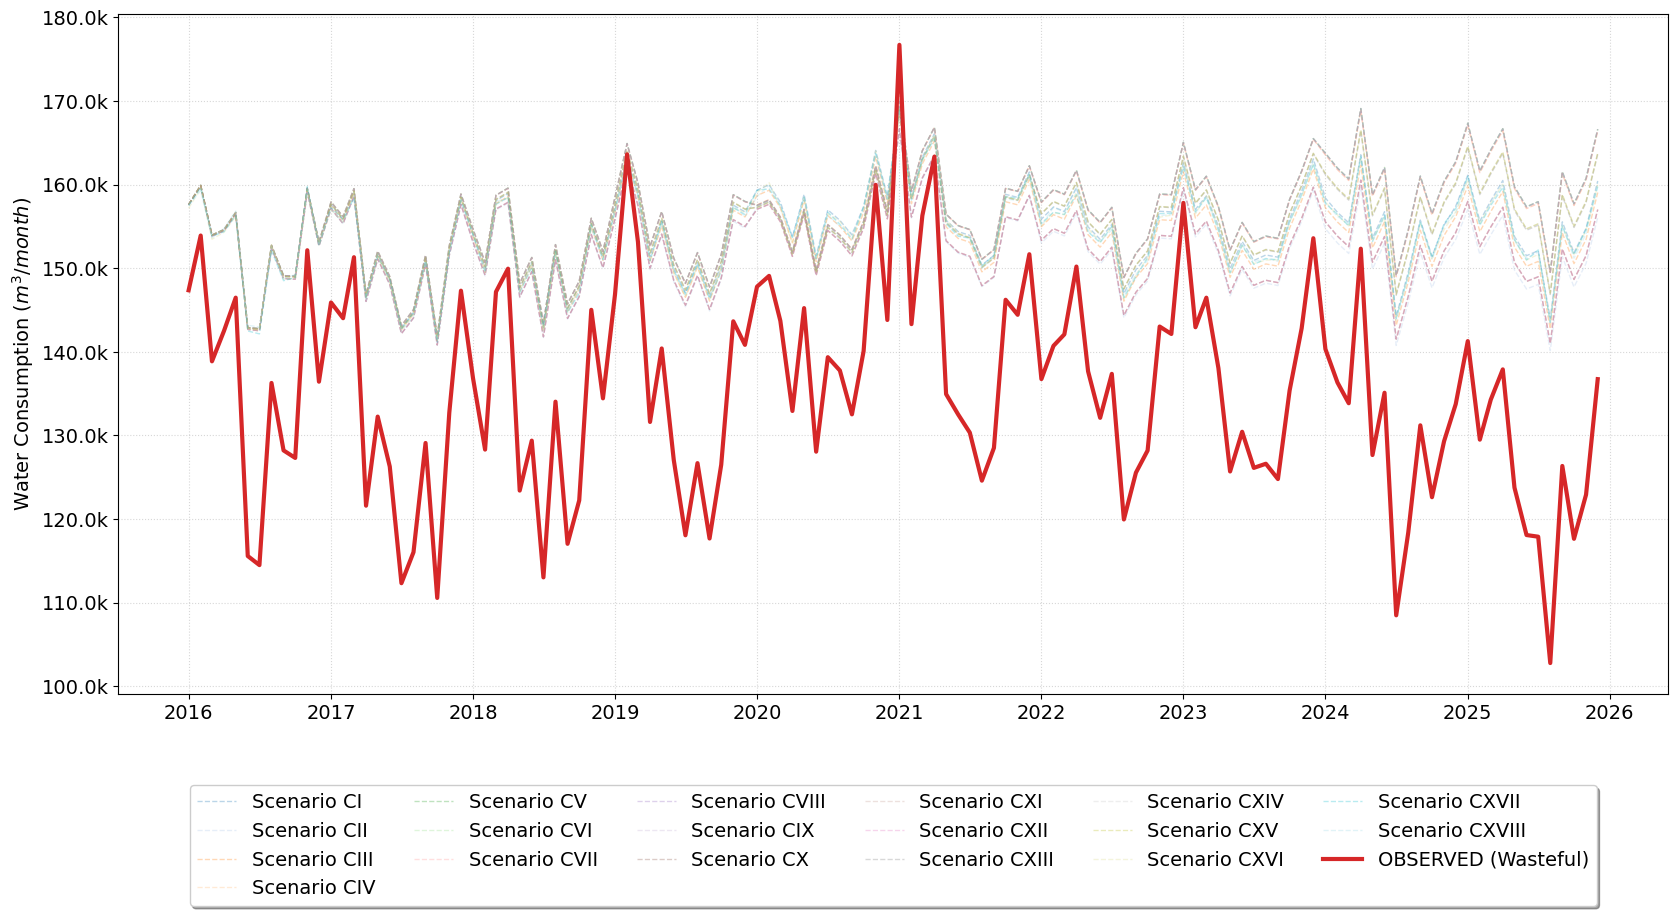

Plotting Monthly AMBIENTALISTA...


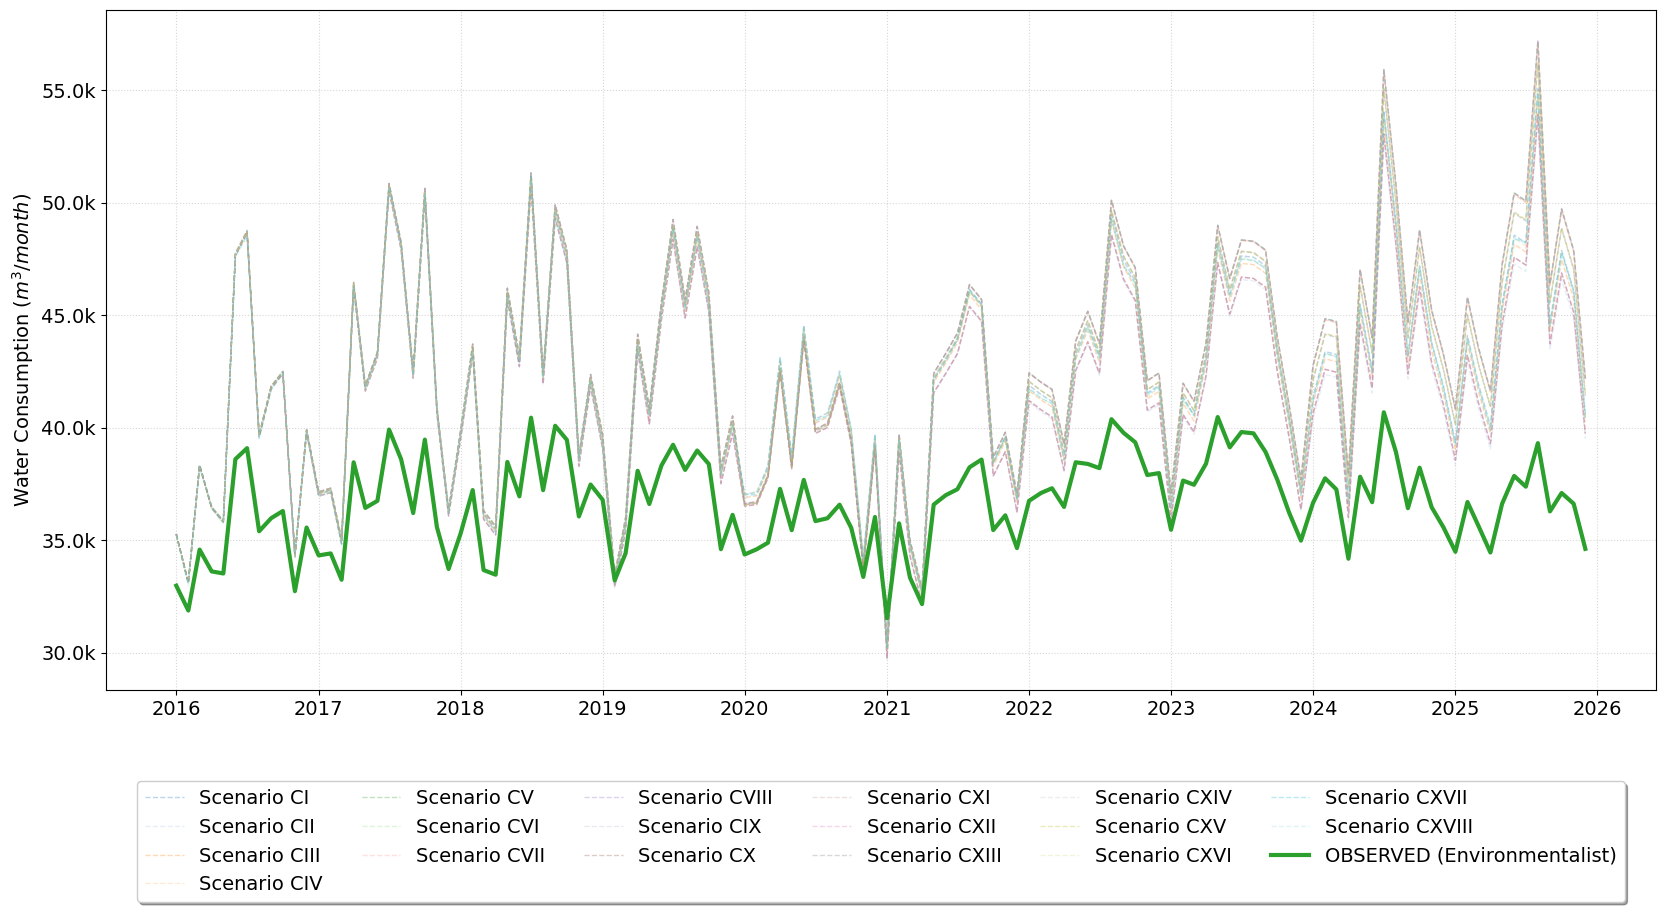

Plotting Monthly MODERADO...


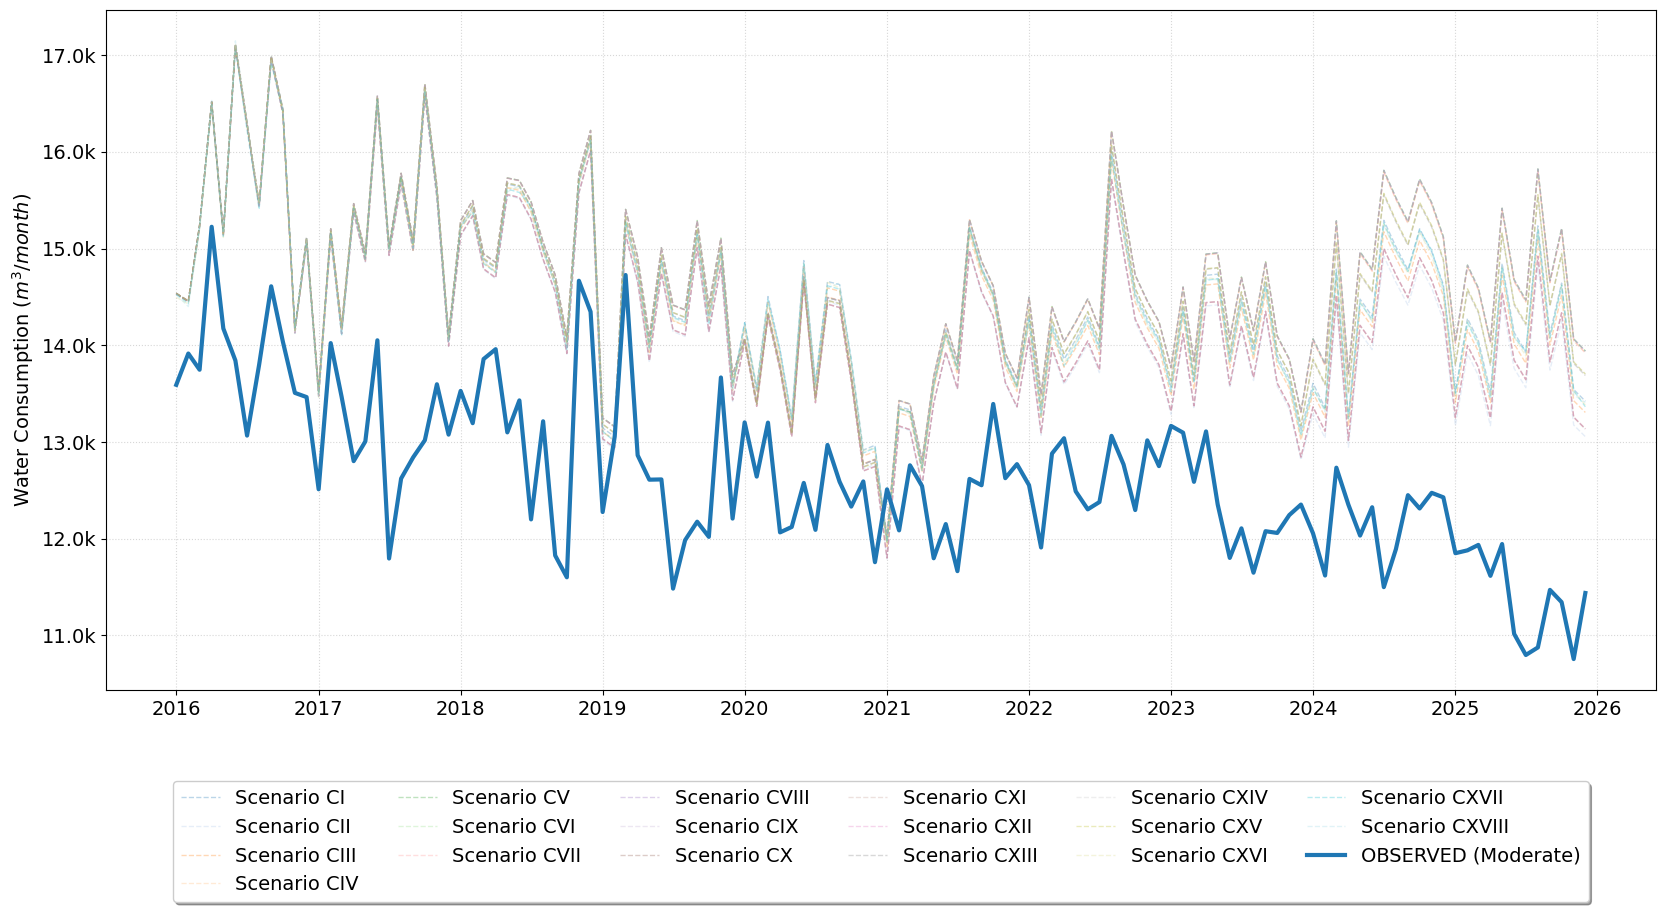

Monthly profile charts saved in ..\figuras


In [3]:
import pandas as pd

import matplotlib.pyplot as plt

import matplotlib.ticker as mticker

import matplotlib.dates as mdates

import numpy as np

import os



# ==========================================

# 1. Configurations and Paths

# ==========================================

BASE_PATH = '..'



# Input Filenames

BASELINE_FILE = 'Tabela_consumidores_Itapua_com_setor_comportamento_e_renda_2015.csv'

HISTORY_120M = 'Tabela_consumo_Itapua_120m.csv'

TOTAL_HISTORY_FILE = 'Tabela_consumo_real_historico_2016_2025.csv'

SIM_FILE = 'simulacao_hindcasting_2016_2025.csv'



# Search Directories

INPUT_DIR_INCLUDES = os.path.join(BASE_PATH, 'includes')

INPUT_DIR_RESULTS = os.path.join(BASE_PATH, 'resultados')

OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')



def classify_profile(daily_liters):

    if daily_liters < 100.0: return 'AMBIENTALISTA'

    elif daily_liters <= 121.5: return 'MODERADO'

    else: return 'PERDULARIO'



def main():

    print("--- Generating MONTHLY Behavioral Validation Charts ---")



    # ==========================================

    # 2. Data Preparation

    # ==========================================

   

    # A. Real Data

    df_total_ref = pd.read_csv(os.path.join(INPUT_DIR_INCLUDES, TOTAL_HISTORY_FILE), sep=';', decimal='.')

    df_total_ref['Date'] = pd.to_datetime(df_total_ref['AM_REFERENCIA'].astype(str) + '01', format='%Y%m%d')

   

    df_residents = pd.read_csv(os.path.join(INPUT_DIR_INCLUDES, BASELINE_FILE), sep=';')[['SK_MATRICULA', 'NN_MORADORES_ANALISE']]

    df_120m = pd.read_csv(os.path.join(INPUT_DIR_INCLUDES, 'dados', HISTORY_120M), sep=';', decimal=',')

    df_120m = df_120m[(df_120m['AM_REFERENCIA'] >= 201601) & (df_120m['AM_REFERENCIA'] <= 202512)]



    # Proportions

    df_dynamic = pd.merge(df_120m, df_residents, on='SK_MATRICULA')

    df_dynamic['L_P_DAY'] = (df_dynamic['HCLQTCON'] * 1000 / df_dynamic['NN_MORADORES_ANALISE']) / 30.5

    df_dynamic['PROFILE'] = df_dynamic['L_P_DAY'].apply(classify_profile)

    monthly_sum = df_dynamic.groupby(['AM_REFERENCIA', 'PROFILE'])['HCLQTCON'].sum().unstack(fill_value=0)

    monthly_prop = monthly_sum.div(monthly_sum.sum(axis=1), axis=0).reset_index()



    # B. Simulation Data

    df_sim = pd.read_csv(os.path.join(INPUT_DIR_RESULTS, SIM_FILE), sep=';', decimal=',')

    df_sim['Date'] = pd.to_datetime(df_sim['Ano'].astype(str) + '-' + df_sim['Mes'].astype(str) + '-01')

    df_sim['AM_REFERENCIA'] = (df_sim['Ano'] * 100 + df_sim['Mes']).astype(int)

    sim_cols = [c for c in df_sim.columns if c not in ['Mes', 'Ano', 'Mes_Ano', 'Date', 'AM_REFERENCIA']]



    # ==========================================

    # 3. Plotting Loop

    # ==========================================

    profiles_config = {

        'PERDULARIO': {'color': '#d62728', 'label': 'Wasteful'},

        'AMBIENTALISTA': {'color': '#2ca02c', 'label': 'Environmentalist'},

        'MODERADO': {'color': '#1f77b4', 'label': 'Moderate'}

    }



    os.makedirs(OUTPUT_DIR, exist_ok=True)



    for p_key, p_info in profiles_config.items():

        print(f"Plotting Monthly {p_key}...")

       

        # Decompose Real Data (Monthly)

        df_p_real = pd.merge(df_total_ref, monthly_prop[['AM_REFERENCIA', p_key]], on='AM_REFERENCIA')

        df_p_real['P_REAL_CONS'] = df_p_real['real_total_consumption'] * df_p_real[p_key]

        df_p_real = df_p_real.sort_values('Date')

       

        # Decompose Scenario Data (Monthly)

        df_p_sim = pd.merge(df_sim, monthly_prop[['AM_REFERENCIA', p_key]], on='AM_REFERENCIA')

        for col in sim_cols:

            df_p_sim[col] = df_p_sim[col] * df_p_sim[p_key]

        df_p_sim = df_p_sim.sort_values('Date')



        # Plot

        fig, ax = plt.subplots(figsize=(20, 10))

       

        # Scenarios (Dashed Lines - Detailed Monthly)

        palette = plt.cm.tab20(np.linspace(0, 1, len(sim_cols)))

        for i, col in enumerate(sim_cols):

            scen_name = col.split('_')[0]

            ax.plot(df_p_sim['Date'], df_p_sim[col], color=palette[i],

                    linestyle='--', alpha=0.3, linewidth=1.0, label=f"Scenario {scen_name}")



        # Real Observed Line (Thick Solid - Detailed Monthly)

        ax.plot(df_p_real['Date'], df_p_real['P_REAL_CONS'],

                color=p_info['color'], label=f'OBSERVED ({p_info["label"]})',

                linewidth=3.0, zorder=30)



        # Formatting

        #ax.set_title(f'Monthly Behavioral Validation: {p_info["label"]} (2016-2025)', fontsize=18, fontweight='bold', pad=25)

        ax.set_ylabel('Water Consumption ($m^3/month$)', fontsize=14)

       

        # X-Axis Time Formatting

        ax.xaxis.set_major_locator(mdates.YearLocator())

        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

        plt.xticks(rotation=0, fontsize=14)

       

        # Y-Axis Scaling

        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.1f}k'))

       

        # Set font size for y-axis tick labels

        for label in ax.get_yticklabels():

            label.set_fontsize(14)

       

       

        plt.grid(True, linestyle=':', alpha=0.5)



        # Legend at Footer

        plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),

                    ncol=6, fontsize=14, frameon=True, shadow=True)



        plt.subplots_adjust(bottom=0.20)

       

        # Save and Show

        output_name = f'figure-validation-profile-monthly-{p_key.lower()}.pdf'

        plt.savefig(os.path.join(OUTPUT_DIR, output_name), format='pdf', bbox_inches='tight')

        plt.show()



    print(f"Monthly profile charts saved in {OUTPUT_DIR}")



if __name__ == "__main__":

    main() 

